In [23]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [24]:
import pandas as pd
nombre_csv_logs="presentacion1_resultados.csv"
# file_path = 'data_set_limpio.pkl'
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print("shape: ",df.shape)
print(df.columns)
df.sample(n=5)


shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,Age,Wage,AT Apps,AT Gls,Team,Caps,Yth Apps,Style,Rc Injury,Best Role,Best Duty,Best Pos,Acc,Aer,Agg,Agi,Ant,Bal,Bra,Cmd,Com,Cmp,Cnt,Cor,Cro,Dec,Det,Dri,Ecc,Fin,Fir,Fla,Fre,Han,Hea,Jum,Kic,Ldr,Lon,L Th,Mar,Nat .1,OtB,1v1,Pac,Pas,Pen,Pos,Pun,Ref,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
91814,ROU,-,Bucovina Rădăuţi,Romania,Right Only,Very Strong,Weak,M (C),180,71,20,500,30,1,-,0,0,Physical,-,Mezzala,Support,M (C),11,2,7,14,8,7,3,1,4,4,6,6,3,14,5,2,1,5,7,8,4,2,4,10,3,4,6,1,12,14,4,3,14,9,1,7,2,3,3,10,7,7,7,9,2,7,11,67500
45764,CZE,Slovak First Division,Skalica,Slovakia (First Division),Right,Very Strong,Weak,AM (LC),186,77,22,1300,44,4,-,0,0,Physical,-,Inverted Winger,Support,AM (L),12,2,13,11,9,8,8,3,2,6,9,8,10,8,18,13,3,9,14,13,3,3,7,11,2,9,9,7,7,14,14,3,11,9,6,7,2,2,3,11,13,4,8,9,3,13,13,275000
55260,NED,Belgian First National Division,Hoogstraten,Belgium (First National Division),Right,Very Strong,Fairly Strong,D/WB (RL),171,70,22,650,28,0,-,0,0,Technical,-,Full-Back,Support,D (R),11,1,11,11,9,8,9,2,1,9,10,6,11,9,7,8,1,6,10,10,4,2,6,7,2,7,8,9,9,13,11,3,11,10,6,10,3,1,1,9,6,11,13,10,1,9,13,12000
25472,BRA,-,-,Brazil,Right,Very Strong,Weak,D (C),194,86,25,0,0,0,-,0,0,Physical,-,Central Defender,Defend,D (C),13,2,8,9,9,7,9,3,2,5,9,2,1,13,10,2,2,2,7,5,1,3,13,14,2,11,5,2,13,11,5,2,11,7,4,12,3,1,1,13,10,13,6,2,1,3,8,0
29688,MEX,Mexican First Division,Santos Laguna,Mexico (First Division),Right,Very Strong,Reasonable,M (C),170,58,22,2100,49,3,-,0,0,Technical,-,Central Midfielder,Attack,M (C),12,1,12,11,10,15,8,3,3,9,10,9,9,15,11,12,2,7,15,7,9,2,8,8,2,11,8,3,9,12,11,2,12,11,6,10,3,1,2,8,7,11,9,11,3,10,13,205000


# Generar conjuntos de entrenamiento y test

In [25]:
import pandas as pd
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test,
                filepath=f"{raiz}{nombre_csv_logs}.csv"):
    params_dict = model.get_params()
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)
    params = json.dumps(params_dict)

    y_pred = model.predict(X_test)

    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    row = {
        "method":          method_name,
        "hyperparameters": json.dumps(params),
        "r2_train":        r2_train,
        "r2_test":         r2_test,
        "mae":             mae,
        "rmse":            rmse
    }

    residuals = y_test - y_pred
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='red', linestyle='--')
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")

    plt.suptitle(method_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  R² train : {r2_train:.4f}")
    print(f"  R² test  : {r2_test:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  RMSE     : {rmse:.2f}")

    try:
        df_log = pd.read_csv(filepath)
        df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df_log = pd.DataFrame([row])

    df_log.to_csv(filepath, index=False)

# Generar conjuntos de entrenamiento y test

In [26]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [27]:
import clustering as cl

kmeans_model_club = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")


train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)



# Considerar solo las más importantes
Si previamente ejecutamos el algoritmo y ya tenemos el archivo

In [28]:
import json
target="transfer_value_estimado"
with open("importantes.json", "r") as f:
    cols_to_keep = json.load(f)
    
cols_to_keep.append(target)
train_df=train_df[cols_to_keep]
test_df=train_df[cols_to_keep]

In [29]:
drop_columns=["Club","Nat","Division",target]
X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

In [30]:
X_train.columns

Index(['Wage', 'Age', 'Based', 'Acc', 'Caps', 'Pac', 'Club_cluster', 'Cmp',
       'Dec', 'Str', 'Team', 'Bal', 'Dri', 'AT Gls', 'Tec', 'Tea', 'Mar',
       'Position', 'Height', 'AT Apps', 'Pen', 'Right Foot', 'L Th', 'Wor',
       'Han', 'Ant', 'Cor', 'Vis', 'Com', 'Preferred Foot', 'Yth Apps', 'Cro',
       'Fir', 'Best Pos', 'Ref', 'Jum', 'Aer', 'Pos', 'Nat_cluster',
       'Division_cluster'],
      dtype='object')

## One Hot para las features categóricas

In [31]:
# import numpy as np
# # categorical_cols=["Nat_cluster","Division_cluster","Club_cluster","Preferred Foot","Right Foot","Left Foot","Best Pos","Best Duty","Style","Best Role","Rc Injury"]
# categorical_cols=["Nat_cluster","Division_cluster","Best Duty","Style"]
# X_train = pd.get_dummies(X_train, columns=categorical_cols)
# X_test  = pd.get_dummies(X_test, columns=categorical_cols)

# X_train, X_test = X_train.align(X_test, join='left', axis=1,fill_value=0)

In [32]:
# X_train = X_train.select_dtypes(include=[np.number,np.bool_])
# X_test = X_test.select_dtypes(include=[np.number,np.bool_])

In [33]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )

# X_test = pd.DataFrame(
#     scaler.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

# Entrenamiento

In [34]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Identify categorical columns
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Categorical columns: {cat_cols}")

# 2. Copy datasets
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 3. Encode all categorical columns
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_encoded[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

X_test_encoded[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

# 4. Train model
model = HistGradientBoostingRegressor()

# 

Categorical columns: ['Based', 'Team', 'Position', 'Right Foot', 'Preferred Foot', 'Best Pos']


# Entrenamiento y Evaluación

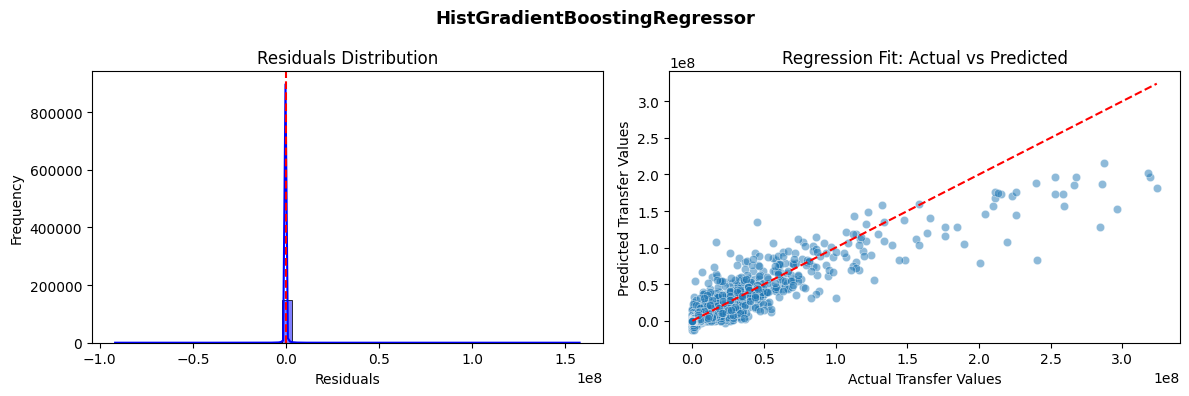

  R² train : 0.8393
  R² test  : 0.8393
  MAE      : 279802.00
  RMSE     : 1932420.28


In [35]:
model.fit(X_train_encoded, y_train)
# model.fit(X_train_encoded, y_train)

# # 5. Predict
preds = model.predict(X_test_encoded)
log_results(model,"HistGradientBoostingRegressor",X_train_encoded,y_train,X_test_encoded,y_test,filepath=nombre_csv_logs)

In [36]:
preds = model.predict(X_test_encoded)
print("saco ",model.score(X_test_encoded,y_test))
preds

saco  0.8392784979465368


array([103656.95765831,  36939.71983283,  31813.10909097, ...,
       148309.69049194,  13958.51866769,  62504.93155467], shape=(149436,))

# Feature importance

In [37]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,          # trained HistGradientBoostingRegressor
    X_test_encoded,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_test_encoded.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    392582.705346     2346.188496
1                Age    209364.821855     2509.940944
2              Based     25164.678468      938.042949
5                Pac     22251.451850      867.626595
10              Team     12922.362162      580.969651
25               Ant     12500.706794      258.111359
27               Vis     11617.015577      629.651381
7                Cmp     11190.388938      423.097399
19           AT Apps     10887.078804      260.093520
3                Acc     10466.142168      637.547519
8                Dec      9413.401826      647.196079
23               Wor      5820.142629      237.136867
14               Tec      5697.299899      193.735309
6       Club_cluster      5409.062076       43.414542
11               Bal      5190.500821      108.827974
4               Caps      4973.572089      110.500137
32               Fir      4475.609988      179.001657
12               Dri      42

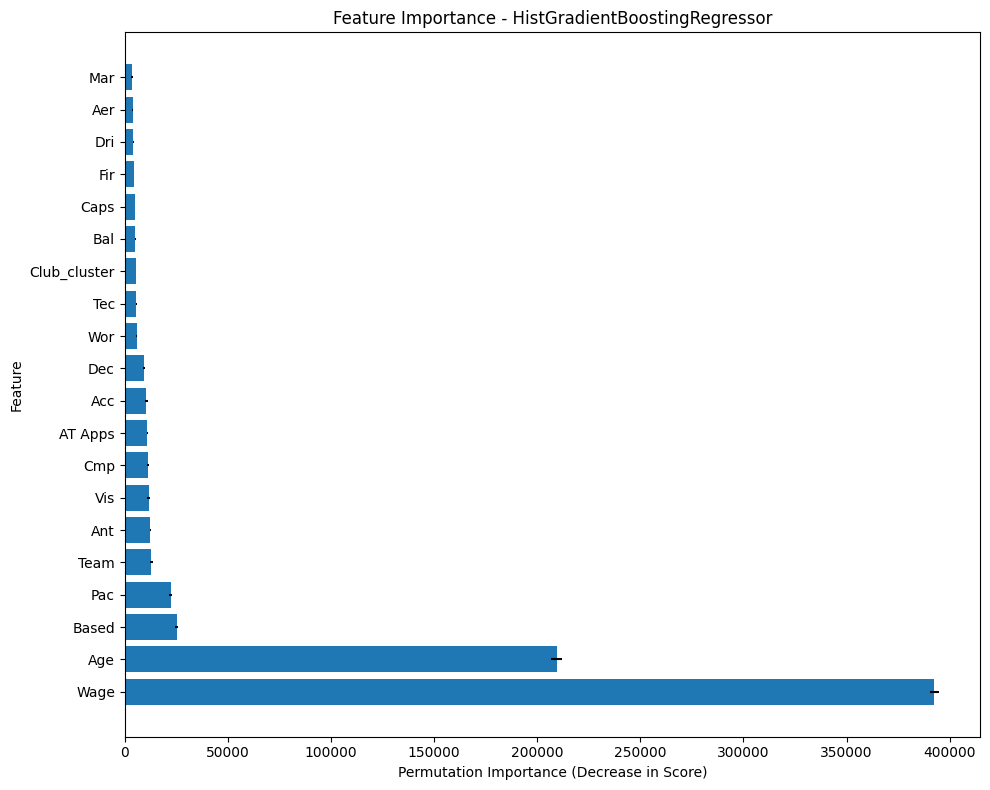

In [38]:
import matplotlib.pyplot as plt

# Optional: keep only top N features
top_n = 20
plot_df = importance_df.head(top_n)

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar plot
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

# Labels and title
plt.xlabel("Permutation Importance (Decrease in Score)")
plt.ylabel("Feature")
plt.title("Feature Importance - HistGradientBoostingRegressor")

# Highest importance at top
# plt.gca().invert_yaxis()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()

In [39]:
import pandas as pd
visualizar_todo=True
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    392582.705346     2346.188496
1                Age    209364.821855     2509.940944
2              Based     25164.678468      938.042949
5                Pac     22251.451850      867.626595
10              Team     12922.362162      580.969651
25               Ant     12500.706794      258.111359
27               Vis     11617.015577      629.651381
7                Cmp     11190.388938      423.097399
19           AT Apps     10887.078804      260.093520
3                Acc     10466.142168      637.547519
8                Dec      9413.401826      647.196079
23               Wor      5820.142629      237.136867
14               Tec      5697.299899      193.735309
6       Club_cluster      5409.062076       43.414542
11               Bal      5190.500821      108.827974
4               Caps      4973.572089      110.500137
32               Fir      4475.609988      179.001657
12               Dri      42

In [40]:
genera_json=False
if genera_json:
    importantes=importance_df.loc[importance_df["importance_mean"] >= 0, "feature"].unique()
    importantes=importantes.tolist()
    import json

    with open("importantes.json", "w") as f:
        json.dump(importantes, f)


# Grid search

In [41]:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'regressor__max_iter': [100, 200],
#     'regressor__learning_rate': [0.01, 0.1],
#     'regressor__max_leaf_nodes': [31, 63],
#     # You can even tune the preprocessor!
#     'prep__high_card__smooth': ['auto', 1.0] 
# }
# gbr_cv = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
# gbr_cv.fit(X_train, y_train)

## Evaluación

In [42]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# y_pred = gbr_cv.predict(X_test)
# mae=mean_absolute_error(y_test, y_pred)
# mse=mean_squared_error(y_test, y_pred)
# r2s=r2_score(y_test, y_pred)

# print("Best parameters ",gbr_cv.best_params_)
# print("mean_absolute_error: ",mae)
# print("mean_squared_error: ",mse)
# print("r2_score: ",r2s)